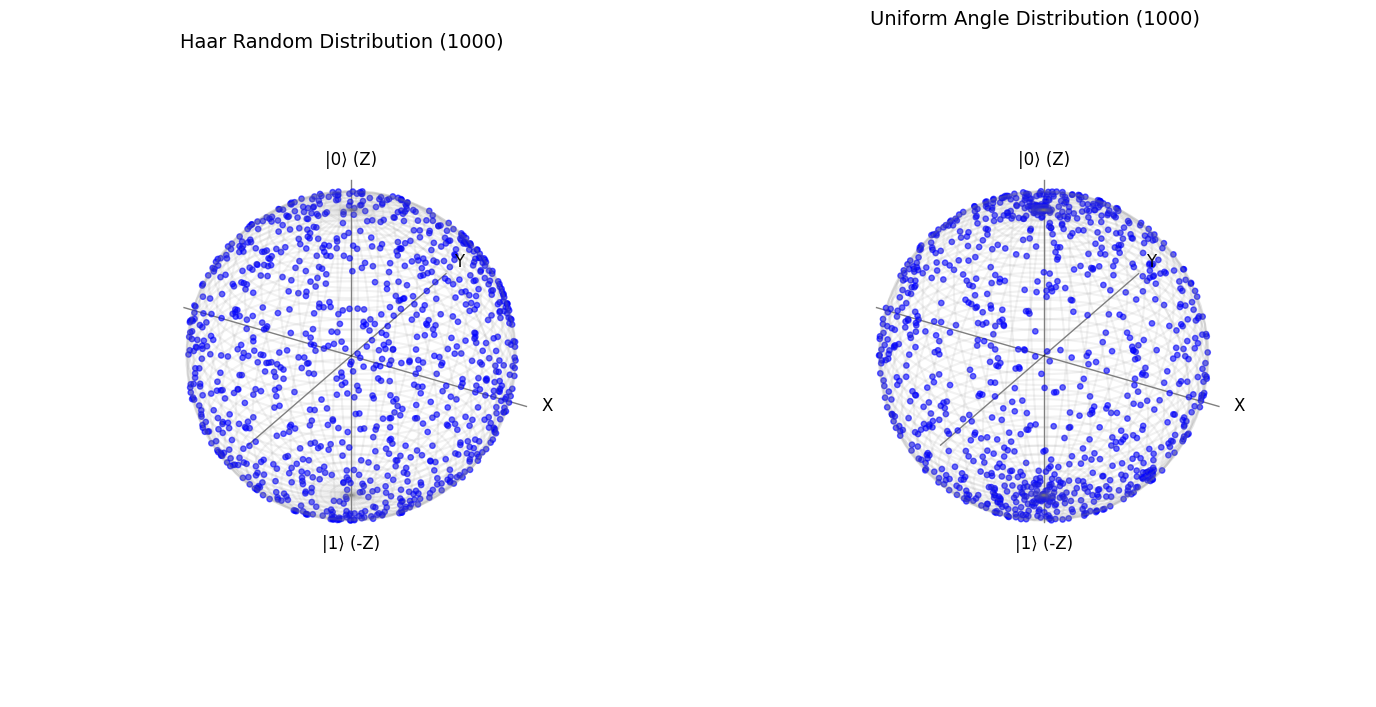

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np


def haar_random_states(dim: int, batch_size: int) -> list[torch.Tensor]:
    """Generates random quantum states uniformly distributed according to the Haar measure."""
    states = []
    for _ in range(batch_size):
        # Generate real and imaginary parts using a standard normal distribution
        real = torch.randn(dim, dtype=torch.float64)
        imag = torch.randn(dim, dtype=torch.float64)
        v = torch.complex(real, imag)
        # Normalize the vector
        v = v / v.norm()
        states.append(v)
    return states


def uniform_angle_states(batch_size: int) -> list[torch.Tensor]:
    """Generates quantum states by uniformly sampling the angles theta and phi."""
    states = []
    # Generate theta uniformly in [0, pi] and phi uniformly in [0, 2*pi]
    thetas = torch.rand(batch_size, dtype=torch.float64) * torch.pi
    phis = torch.rand(batch_size, dtype=torch.float64) * 2 * torch.pi

    for theta, phi in zip(thetas, phis):
        # Qubit state: cos(theta/2)|0> + e^{i*phi}sin(theta/2)|1>
        alpha = torch.cos(theta / 2)

        # Calculate the real and imaginary parts for beta
        sin_t2 = torch.sin(theta / 2)
        beta_real = sin_t2 * torch.cos(phi)
        beta_imag = sin_t2 * torch.sin(phi)

        # Construct complex tensors
        beta = torch.complex(beta_real, beta_imag)
        alpha_cplx = torch.complex(alpha, torch.tensor(0.0, dtype=torch.float64))

        v = torch.tensor([alpha_cplx, beta], dtype=torch.complex128)
        states.append(v)

    return states


def get_bloch_coordinates(states: list[torch.Tensor]) -> tuple[list[float], list[float], list[float]]:
    """Converts a list of 2D quantum states into 3D Bloch sphere coordinates (x, y, z)."""
    x_coords, y_coords, z_coords = [], [], []

    for v in states:
        alpha = v[0]
        beta = v[1]

        # Calculate Bloch vector components
        x = 2 * (alpha.conj() * beta).real.item()
        y = 2 * (alpha.conj() * beta).imag.item()
        z = (torch.abs(alpha) ** 2 - torch.abs(beta) ** 2).item()

        x_coords.append(x)
        y_coords.append(y)
        z_coords.append(z)

    return x_coords, y_coords, z_coords


def plot_bloch_sphere(ax, x_coords, y_coords, z_coords, title):
    """Helper function to draw the Bloch sphere and scatter the state points."""
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="gray", alpha=0.1)

    ax.plot([-1.2, 1.2], [0, 0], [0, 0], color="black", lw=1, alpha=0.5)
    ax.plot([0, 0], [-1.2, 1.2], [0, 0], color="black", lw=1, alpha=0.5)
    ax.plot([0, 0], [0, 0], [-1.2, 1.2], color="black", lw=1, alpha=0.5)

    ax.text(1.3, 0, 0, "X", color="black", fontsize=12)
    ax.text(0, 1.3, 0, "Y", color="black", fontsize=12)
    ax.text(0, 0, 1.3, "|0⟩ (Z)", color="black", fontsize=12, ha="center")
    ax.text(0, 0, -1.4, "|1⟩ (-Z)", color="black", fontsize=12, ha="center")

    ax.scatter(x_coords, y_coords, z_coords, color="blue", s=15, alpha=0.6)

    ax.set_box_aspect([1, 1, 1])
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.axis("off")
    ax.set_title(title, fontsize=14, y=1.05)


NUM_STATES = 1000

# Generate states using both methods
haar_states = haar_random_states(dim=2, batch_size=NUM_STATES)
uniform_states = uniform_angle_states(batch_size=NUM_STATES)

# Get Bloch coordinates for both
hx, hy, hz = get_bloch_coordinates(haar_states)
ux, uy, uz = get_bloch_coordinates(uniform_states)

fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(121, projection="3d")
plot_bloch_sphere(ax1, hx, hy, hz, f"Haar Random Distribution ({NUM_STATES})")

ax2 = fig.add_subplot(122, projection="3d")
plot_bloch_sphere(ax2, ux, uy, uz, f"Uniform Angle Distribution ({NUM_STATES})\n")

plt.tight_layout()
plt.show()